In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import bayesflow as bf

INFO:bayesflow:Using backend 'jax'


In [7]:
from src.simulations.molecules import MoleculeSimulator
from src.simulations.benchmarks.ethene import ethene, ethene_configs
from pathlib import Path

In [8]:
checkpoint_path = Path("checkpoints")
checkpoint_path.mkdir(parents=True, exist_ok=True)

## Simulator + Dataset

In [9]:
ethene_simulator = MoleculeSimulator(
    molecule_fun=ethene,
    basis="cc-pVDZ",
    coord_scale=1.,
    cache_integrals=False
)

In [10]:
# Prior function to sample geometric configuration for ethene
ethene_configs = ethene_configs

In [ ]:
training_set = ethene_simulator.sample(
    batch_size=10000,
    molecule_config=ethene_configs,
    molecule_kwargs={ "perturb": False },
    include_kwargs={
        "include_hartree_fock": True,
        "include_configs": True,
    }
)

Generating samples:   4%|▍         | 386/10000 [05:19<2:17:02,  1.17it/s]

In [320]:
validation_set = ethene_simulator.sample(
    batch_size=500,
    molecule_config=ethene_configs,
    molecule_kwargs={ "perturb": False },
    include_kwargs={
        "include_hartree_fock": True,
        "include_configs": True,
    }
)

Generating samples: 100%|██████████| 500/500 [06:46<00:00,  1.23it/s]


## Adapter

In [344]:
inference_variables = ["cc_bond_distance", "ch_bond_distance", "hch_angle", "twist_angle", "hf_energy"]
inference_conditions = ["determinant", "occupancies"]

adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .scale(["hch_angle", "twist_angle"], by=1./180)
    .concatenate(inference_conditions, axis=-1, into="inference_conditions")
    .concatenate(inference_variables, into="inference_variables")
)

### Flow Matching

In [303]:
flow_matching = bf.networks.FlowMatching()

In [348]:
flow_matching_workflow = bf.workflows.BasicWorkflow(
    simulator=ethene_simulator,
    adapter=adapter,
    inference_network=flow_matching,
    checkpoint_filepath=checkpoint_path / "ethene_flow_matching.ckpt"
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [349]:
flow_matching_history = flow_matching_workflow.fit_offline(
    data=training_set,
    val_data=validation_set,
    epochs=100,
    batch_size=32
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 4.3809
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6454
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3253
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.0389
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.3468
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8817
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7645
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4181
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.5566
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.2997
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.4208
Epoch 12/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9652
Epoch 13/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.1402
Epoch 14/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9454
Epoch 15/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 1

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at 'checkpoints/ethene_flow_matching.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


In [350]:
fig_size = (15, 3)
variable_names = [r"$D_{\text{C-C}}$", r"$D_{\text{C-H}}$", r"$\theta$", r"$\phi$", r"$E_{\text{HF}}$"]

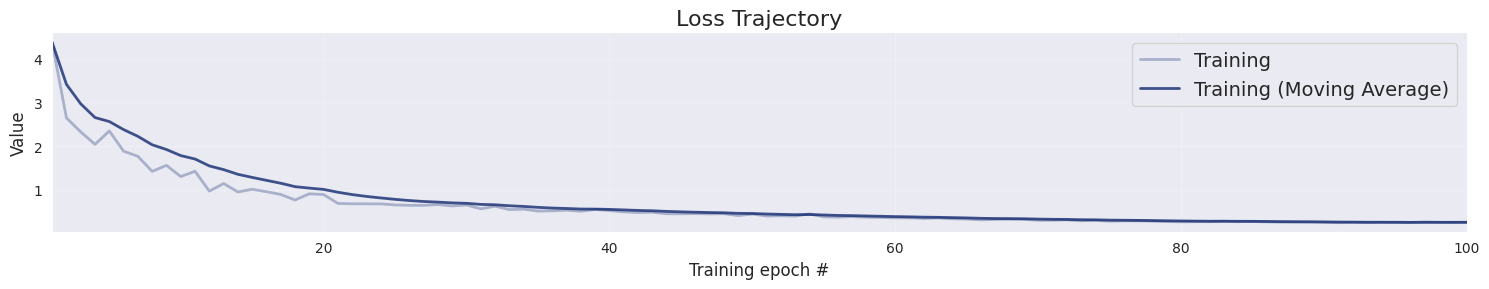

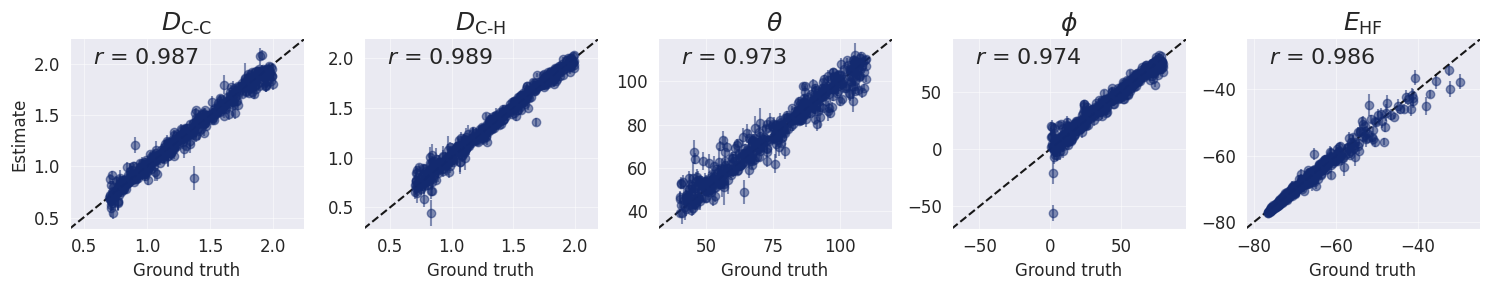

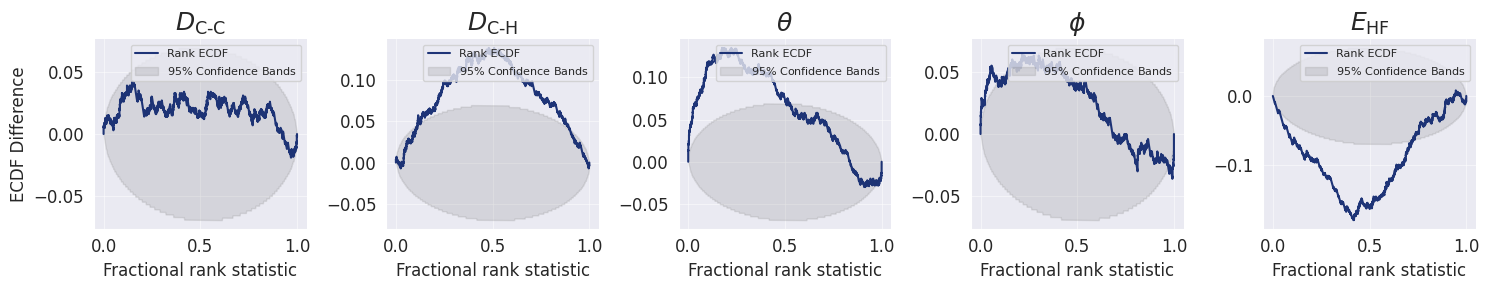

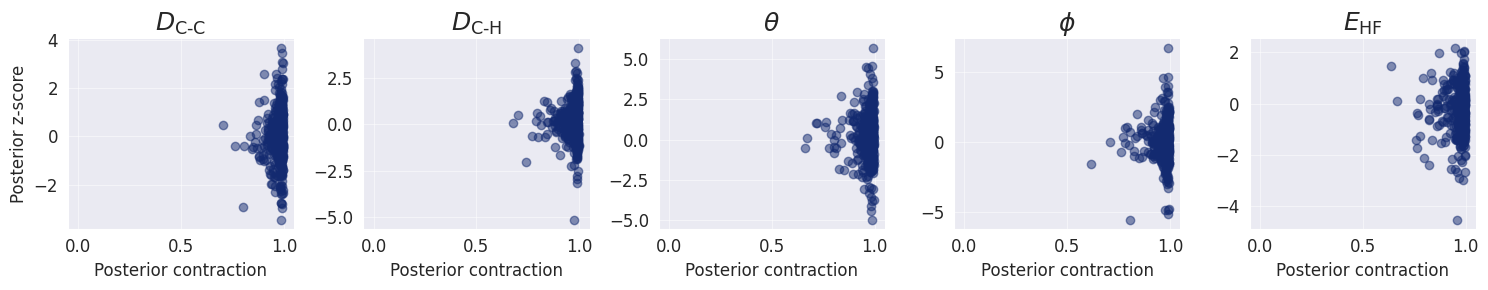

In [351]:
figures = flow_matching_workflow.plot_default_diagnostics(
    test_data=validation_set,
    variable_names=variable_names,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    recovery_kwargs={"figsize": fig_size, "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": fig_size, "legend_fontsize": 8, "difference": True,
                             "label_fontsize": 12},
    z_score_contraction_kwargs={"figsize": fig_size, "label_fontsize": 12}
)

In [ ]:
metrics = flow_matching_workflow.compute_default_diagnostics(test_data=validation_set)

## Diffusion Model

In [1]:
diffusion_model = bf.networks.DiffusionModel()

NameError: name 'bf' is not defined

In [ ]:
diffusion_workflow = bf.workflows.BasicWorkflow(
    simulator=ethene_simulator,
    adapter=adapter,
    inference_network=diffusion_model,
    checkpoint_filepath=checkpoint_path / "ethene_diffusion.ckpt"
)

In [ ]:
diffusion_history = diffusion_workflow.fit_offline(
    data=training_set,
    val_data=validation_set,
    epochs=100,
    batch_size=32
)

In [ ]:
figures = diffusion_workflow.plot_default_diagnostics(
    test_data=validation_set,
    variable_names=variable_names,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 12},
    recovery_kwargs={"figsize": fig_size, "label_fontsize": 12},
    calibration_ecdf_kwargs={"figsize": fig_size, "legend_fontsize": 8, "difference": True,
                             "label_fontsize": 12},
    z_score_contraction_kwargs={"figsize": fig_size, "label_fontsize": 12}
)